# EC classification



Install NCBI BLAST+ 2.17.0 : https://ftp.ncbi.nlm.nih.gov/blast/executables/blast+/LATEST/

In [76]:
#install blastp (protein)
!blastp -version  

blastp: 2.17.0+
 Package: blast 2.17.0, build Jul  1 2025 08:59:26


In [77]:
import pandas as pd
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq 
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

==========================================
# Data Importing and Cleaning

## Data
Download the EC classification dataset from HuggingFace: https://huggingface.co/datasets/tattabio/ec_classification/tree/main/data
* test-00000-of-00001.parquet
* train-00000-of-00001.parquet

In [78]:
df_test = pd.read_parquet("data/test-00000-of-00001.parquet")
##print(df_test)  

df_train= pd.read_parquet("data/train-00000-of-00001.parquet")
#print(df_train)  

Build the custom database using the train set

In [79]:
#Transform train set DataFrame to fasta, using biopython.
records = []
for _, row in df_train.iterrows(): 
    record = SeqRecord(
        Seq(row['Sequence']),
        id=row['Entry'],
        description=str(row['Label'])
    )
    records.append(record)

SeqIO.write(records, "train.fasta", "fasta")

#Custom database using makeblastdb
!makeblastdb -in train.fasta -title train -dbtype prot -out train/train -parse_seqids

# References
# 1. https://biopython.org/docs/1.76/api/Bio.SeqIO.html
# 2. https://www.ncbi.nlm.nih.gov/genbank/fastaformat/
# 3. https://conmeehan.github.io/blast+tutorial.html



Building a new DB, current time: 05/04/2026 10:16:41
New DB name:   /Users/suryun/My Drive/0_2026_1_Spring/CS690 Bioinformatics/cs690_project/0504_code/train/train
New DB title:  train
Sequence type: Protein
Deleted existing Protein BLAST database named /Users/suryun/My Drive/0_2026_1_Spring/CS690 Bioinformatics/cs690_project/0504_code/train/train
Keep MBits: T
Maximum file size: 3000000000B
Adding sequences from FASTA; added 512 sequences in 0.103541 seconds.


BLAST Database error: No alias or index file found for protein database [/Users/suryun/My] in search path [/Users/suryun/My Drive/0_2026_1_Spring/CS690 Bioinformatics/cs690_project/0504_code::]. Please verify the spelling of the BLAST database and its molecule type.


In [80]:
#Transform test set DataFrame to fasta, using biopython.
records = []
for _, row in df_test.iterrows():
    record = SeqRecord(
        Seq(row['Sequence']),
        id=row['Entry'],
        description=str(row['Label'])
    )
    records.append(record)

SeqIO.write(records, "test.fasta", "fasta")

128

===============================================
# Perform BLASTP with various E-values 
* Find the one best matching sequence (Subject_id) from my custom database (512 sequences) for each query sequence (Query_id) 

## (1) E-value = 1e-5
* (1-1) E=1e-5 has been predetermined as the stringent cutoff. Begin BLASTP from the most stringent E-value

In [81]:
# performing BLASTp search : E-value cut off = 1e-5 (pre-determined stringent E-value )
!blastp -query test.fasta -db train/train -out results.txt  -num_alignments 1 -evalue 1e-5  -outfmt 6

#-num_alignments 1 -> find only one top hit (the sequence having lowest E-value)

In [82]:
#displaying sequences have a top hit with E=1e-5
!cat results.txt 

O46310	Q6R7K3	28.000	300	202	7	36	325	73	368	1.20e-26	105
Q5UQV6	Q12284	32.558	86	55	1	7	92	82	164	1.83e-12	57.0
Q8IRW8	Q54HS3	49.650	143	69	2	2290	2431	1346	1486	4.10e-40	158
Q6BTC8	Q6C4Y5	44.177	249	132	5	927	1172	243	487	5.10e-51	183
P0DOY1	Q9M548	36.220	127	67	4	450	566	494	616	4.16e-13	67.4
A0LL58	A5W820	50.244	205	99	3	5	207	4	207	9.11e-65	194
Q12006	Q76IC6	39.683	63	38	0	72	134	247	309	1.07e-11	60.5
Q9KTE4	A0QZ13	23.006	539	322	22	12	497	69	567	1.54e-19	86.7
Q5SVQ0	Q8WYB5	55.987	309	132	2	301	609	685	989	9.17e-117	378
Q42868	Q59601	25.735	136	97	3	80	215	50	181	5.00e-07	44.7
Q9ZVX1	F4HPP7	46.237	279	126	4	824	1091	21	286	1.52e-79	258
Q69ZR2	Q9VR91	40.602	133	68	5	1237	1367	1890	2013	1.14e-18	88.6
Q69ZR2	Q9VR91	30.952	168	104	6	2442	2606	4711	4869	2.87e-12	67.4
Q84RQ8	Q1L8G6	21.067	356	230	11	54	368	352	697	1.95e-17	80.1
Q9W5D4	Q06644	22.830	311	211	11	195	485	171	472	1.22e-13	68.9
B4JHJ7	Q09103	47.101	138	70	2	359	494	806	942	4.70e-34	138
B4JHJ7	Q09103	39.247	186	101	4	1482	1663

12 columns: 

1. Query id
2. Subject id  (= Sequence id in the database)
3. % identity
4. alignment length
5. mismatches
6. gap openings
7. query start
8. query end
9. subject start
10. subject end
11. e-value
12. bit score

source: https://conmeehan.github.io/blast+tutorial.html


===> I need only column 1 (Query_id) and column2 (Subject_id). And, going back to original df_train, find its EC class ("Label"in df_train) for Subject id ("Entry" in df_train)

* (1-2) Find the top hit query sequence at E=1e-5 and assign their EC classes to the query sequence. 

In [83]:
#1. query_id : subject_id matched (subject id = sequence_id in training set) (only for having tophits query sequences)
tophit = {}
with open("results.txt") as outputs:
    for line in outputs:
        cols = line.strip().split("\t") #splitting 12 columns with tab
        query_id = cols[0] #query id (column 1)
        subject_id = cols[1] #subject_id (column 2)
        tophit[query_id] = subject_id 

print(tophit)

#The first row of "results.txt"  ==> Query: O46310 (Column 1)- Subject_id: Q6R7K3  (Column2)
#The printed dictionary is consistent as the results.txt.

{'O46310': 'Q6R7K3', 'Q5UQV6': 'Q12284', 'Q8IRW8': 'Q54HS3', 'Q6BTC8': 'Q6C4Y5', 'P0DOY1': 'Q9M548', 'A0LL58': 'A5W820', 'Q12006': 'Q76IC6', 'Q9KTE4': 'A0QZ13', 'Q5SVQ0': 'Q8WYB5', 'Q42868': 'Q59601', 'Q9ZVX1': 'F4HPP7', 'Q69ZR2': 'Q9VR91', 'Q84RQ8': 'Q1L8G6', 'Q9W5D4': 'Q06644', 'B4JHJ7': 'Q09103', 'P03177': 'P23983', 'O25533': 'Q7MS38', 'Q8SQY7': 'P37297', 'Q12866': 'P08581', 'P18160': 'P18161', 'Q54R82': 'Q9WTR2', 'Q54YH4': 'O74539', 'O61069': 'Q8VYL1', 'Q8R753': 'Q54PA9', 'Q57606': 'Q57877', 'Q9VD44': 'Q5U315', 'Q8LKW0': 'Q06163', 'B8GZM2': 'Q9HT84', 'P42494': 'P25615', 'B1AJ41': 'Q8CXQ3', 'A0L6H5': 'A5I308', 'A3MTK6': 'Q97TX9', 'Q8VYU4': 'Q6BMM5', 'O01326': 'Q83FY2', 'Q501F9': 'Q84T94', 'Q7NA60': 'Q5E2G4', 'P40399': 'O07014', 'B4HEM4': 'Q9I7S6', 'Q9HX69': 'Q8EJM6', 'A5FB63': 'Q13231', 'Q556F2': 'P16009', 'P31206': 'P62576', 'Q22492': 'B2UPR7', 'P23031': 'B4XVN1', 'Q8GJ44': 'P29126', 'P59206': 'P39848', 'G8SD34': 'P43254', 'Q6ZQ93': 'Q9NVE5', 'Q695T8': 'Q695T9', 'Q14674': 'P18296',

In [84]:
#2.subject_id (sequence_id in training set): its EC class (one of unique 512 EC classes)
label_dict = dict(zip(df_train['Entry'], df_train['Label'])) #Entry: sequence_id of database (trainset); Label: its EC class 
print(label_dict)
 
#Confirmed that Subject_id (sequence_id): EC class were put together into dictionary well.


{'Q9LQC0': '1.14.14.18', 'A0AFT8': '1.14.14.18', 'P74133': '1.14.14.18', 'O31534': '1.14.14.18', 'P34697': '1.15.1.1', 'P19666': '1.15.1.1', 'P80734': '1.15.1.1', 'Q54RN1': '1.15.1.1', 'Q8U1L4': '1.16.3.1', 'P9WMK7': '1.16.3.1', 'P22759': '1.16.3.1', 'D0LZ73': '1.16.3.1', 'Q6R7K3': '1.17.4.1', 'O55716': '1.17.4.1', 'Q9CBQ2': '1.17.4.1', 'Q9KFH7': '1.17.4.1', 'Q8PU61': '1.5.98.3', 'F1SVE4': '1.5.98.3', 'F1SVL1': '1.5.98.3', 'F1SVE1': '1.5.98.3', 'Q12284': '1.8.3.2', 'P41480': '1.8.3.2', 'Q8JGM4': '1.8.3.2', 'Q91FH7': '1.8.3.2', 'Q54HS3': '2.1.1.354', 'P97443': '2.1.1.354', 'Q84WW6': '2.1.1.354', 'Q75D88': '2.1.1.354', 'Q55AX2': '2.1.1.360', 'Q6C4Y5': '2.1.1.360', 'Q6AW06': '2.1.1.360', 'Q8TEK3': '2.1.1.360', 'Q67472': '2.1.1.37', 'B1Q3J6': '2.1.1.37', 'Q9M548': '2.1.1.37', 'P25265': '2.1.1.37', 'O31504': '2.1.1.72', 'P25201': '2.1.1.72', 'Q9KVZ8': '2.1.1.72', 'Q58724': '2.1.1.72', 'Q8PW90': '2.1.1.77', 'A5W820': '2.1.1.77', 'B0RTZ8': '2.1.1.77', 'Q3SKJ2': '2.1.1.77', 'Q8TU04': '2.1.1.86

In [85]:
#3. query_id : subeject_id: subject_id's EC class (= prdicted EC class for query sequence) only for the query sequences having top hits, Otherwise, assign "no_hit" to each query
records = []
for _, row in df_test.iterrows(): #all of each query sequence (N=128)
    query_id = row['Entry'] #each query sequence id (from df_test)
    if query_id in tophit: #query_id which had top hits in BLASTP search
        subject_id = tophit[query_id] #Matching subject_id (i.e. matched sequence id in the database) to query_id
        pred = label_dict.get(subject_id)  #Assigning EC_class to subject_id
    else:
        subject_id = "No_hit"
        pred = "No_hit" #Assign "No_hit" to the predicted label for the sequences having no top hits at E = 1e-5
    
    records.append({
        "query_seq": query_id,
        "matched_seq": subject_id,
        "predicted_label": pred
    })

df_results = pd.DataFrame(records) 
pd.set_option('display.max_rows', None) 
#print(df_results)

In [86]:
# Count "No_hit"
print((df_results['matched_seq'] == 'No_hit').sum()) #n=57 ====> for these 57 query sequences without hit, will increase E-value to 1e-3, and re-run 

# Count hit
print((df_results['matched_seq'] != 'No_hit').sum()) #n=71 ===> for these 71 query sequences, predicted class assginment completed. 

57
71


# (2) Repeat BLASTP for 57 query sequences (No hit) at E=1e-3

(2-1) Create a new test set fasta file of remained 57 queries.

In [87]:
#Extract No_hit queries (N=57)
nohit_ids = set(df_results[df_results['matched_seq'] == 'No_hit']['query_seq'])
print(nohit_ids)

{'Q9HCN3', 'Q99N23', 'C1D538', 'O74831', 'A2BQ15', 'Q9C103', 'Q810L3', 'B5EGY0', 'Q91YE9', 'Q10916', 'Q9YEK1', 'Q18680', 'Q20EX3', 'G5EC44', 'Q05622', 'Q9ZCD8', 'Q97U94', 'E9AE57', 'Q8C0T9', 'P82543', 'Q6LWZ3', 'A1CE56', 'P39145', 'Q9P8W0', 'Q53547', 'P26831', 'Q5UPY1', 'Q5W6G0', 'P52341', 'P09961', 'Q8PU58', 'A6LRL7', 'Q07606', 'Q824Y6', 'P10329', 'O64792', 'P73335', 'P18539', 'Q5PR55', 'Q09956', 'Q166H0', 'O69583', 'P84786', 'P39421', 'Q6QGE7', 'Q84JU4', 'Q5AD07', 'Q38924', 'A0A5B8NIM2', 'P39049', 'A1A005', 'Q8NFZ0', 'Q93V61', 'P50694', 'P40582', 'A0A0H2XEA6', 'Q67653'}


In [88]:
# Extract queries with "No_hit" to a new fasta file (new test set (subset of the intial test set))--> test1.fasta (# of sequence : n=57)
records_nohit = []
for _, row in df_test.iterrows():
    if row['Entry'] in nohit_ids: #no hit query ids from the dictionary above.
        record = SeqRecord(Seq(row['Sequence']), id=row['Entry'], description=str(row['Label']))
        records_nohit.append(record)

SeqIO.write(records_nohit, "test1.fasta", "fasta")

57

(2-2) Repeat BlastP for a new test set at E=1-e3 (Less stringent e-value)

In [89]:
#Perform BLASTP with E=1e-3 for No hit queries (Repeat the code above with modifying e-value)
!blastp -query test1.fasta -db train/train -out results1.txt  -num_alignments 1 -evalue 1e-3  -outfmt 6

In [90]:
#1. query_id : subject_id matched (subject id = sequence_id in training set) (only for having tophits query sequences)
tophit = {}
with open("results1.txt") as outputs:
    for line in outputs:
        cols = line.strip().split("\t") #splitting 12 columns with tab
        query_id = cols[0] #query id (column 1)
        subject_id = cols[1] #subject_id (column 2)
        tophit[query_id] = subject_id 

#2.subject_id (sequence_id in training set): its EC class (out of 512 EC classes) #performed above. No need to re-run again.
#label_dict = dict(zip(df_train['Entry'], df_train['Label'])) #Entry: sequence_id of database (train set); Label: its EC class 


In [91]:
#3. query_id : subeject_id: subject_id's EC class (= prdicted EC class for query sequence) only for the query sequences having top hits, Otherwise, assign "no_hit" to each query
records1 = []
for _, row in df_test.iterrows():   #all of each query sequence (N=128)
    query_id = row['Entry']        #each query sequence id (from df_test)
    if query_id in nohit_ids:        #query_id from "NOHIT_IDS" (only for 57 queries)
        if query_id in tophit:       #query_id which had top hits in BLASTP search
            subject_id = tophit[query_id]  #Matching subject_id (i.e. matched sequence id in the database) to query_id
            pred = label_dict.get(subject_id)   #Assigning EC_class to subject_id
        else:                       
            subject_id = "No_hit"
            pred = "No_hit"  #Assign "No_hit" to the predicted label for the sequences having no top hits at E = 1e-3
        
        records1.append({
            "query_seq": query_id,
            "matched_seq": subject_id,
            "predicted_label": pred
        })

df_results1 = pd.DataFrame(records1)
#print(df_results1)

In [92]:
# Count "No_hit"
print((df_results1['matched_seq'] == 'No_hit').sum()) #n=52 ====> for these 52 query sequences without hit, will increase E-value to 0.1, and re-run 

# Count hit
print((df_results1['matched_seq'] != 'No_hit').sum()) #n=5 ===> for these 5 query sequences with hit, predicted class assginment completed. 

52
5



# (3) Repeat BLASTP for 52 query sequences (No hit) at E=0.1

(3-1) Create a new test set fasta file of remained 52 queries.

In [93]:
#Extract No_hit queries (N=52)
nohit_ids = set(df_results1[df_results1['matched_seq'] == 'No_hit']['query_seq'])
#print(nohit_ids)

In [94]:
# Extract queries with "No_hit" to a new fasta file (new test set (subset of the intial test set))--> test2.fasta (# of sequence : n=52)
records_nohit = []
for _, row in df_test.iterrows():
    if row['Entry'] in nohit_ids:
        record = SeqRecord(Seq(row['Sequence']), id=row['Entry'], description=str(row['Label']))
        records_nohit.append(record)

SeqIO.write(records_nohit, "test2.fasta", "fasta")

52

(3-2) Repeat BlastP for a new test set at E=0.1 (Less stringent e-value)

In [95]:
#Perform BLASTP with E=0.1 for No hit queries (Repeat the code above with modifying e-value)
!blastp -query test2.fasta -db train/train -out results2.txt  -num_alignments 1 -evalue 0.1  -outfmt 6

In [96]:
#1. query_id : subject_id matched (subject id = sequence_id in training set) (only for having tophits query sequences)
tophit = {}
with open("results2.txt") as outputs:
    for line in outputs:
        cols = line.strip().split("\t") #splitting 12 columns with tab
        query_id = cols[0] #query id (column 1)
        subject_id = cols[1] #subject_id (column 2)
        tophit[query_id] = subject_id 

#2.subject_id (sequence_id in training set): its EC class (out of 512 EC classes) #performed above. No need to re-run again.
#label_dict = dict(zip(df_train['Entry'], df_train['Label'])) #Entry: sequence_id of database (train set); Label: its EC class 


In [97]:
#3. query_id : subeject_id: subject_id's EC class (= prdicted EC class for query sequence) only for the query sequences having top hits, Otherwise, assign "no_hit" to each query
records2 = []
for _, row in df_test.iterrows():    #all of each query sequence (N=128)
    query_id = row['Entry']          #each query sequence id (from df_test)
    if query_id in nohit_ids:        #query_id from "NOHIT_IDS" (only for 52 queries)
        if query_id in tophit:       #query_id which had top hits in BLASTP search
            subject_id = tophit[query_id]  #Matching subject_id (i.e. matched sequence id in the database) to query_id
            pred = label_dict.get(subject_id)  #Assigning EC_class to subject_id
        else:                       
            subject_id = "No_hit"
            pred = "No_hit"  #Assign "No_hit" to the predicted label for the sequences having no top hits at E = 1e-3
        
        records2.append({
            "query_seq": query_id,
            "matched_seq": subject_id,
            "predicted_label": pred
        })

df_results2 = pd.DataFrame(records2)


# Count "No_hit"
print((df_results2['matched_seq'] == 'No_hit').sum()) #n=46 ====> for these 46 query sequences without hit, will increase E-value to 10, and re-run 

# Count hit
print((df_results2['matched_seq'] != 'No_hit').sum()) #n=6 ===> for these 6 query sequences with hit, predicted class assginment completed. 

46
6



# (4) Repeat BLASTP for 46 query sequences (No hit) at E=10

(4-1) Create a new test set fasta file of remained 46 queries.

In [98]:
#Extract No_hit queries (N=46)
nohit_ids = set(df_results2[df_results2['matched_seq'] == 'No_hit']['query_seq'])
#print(nohit_ids)

In [99]:
# Extract queries with "No_hit" to a new fasta file (new test set (subset of the intial test set))--> test3.fasta (# of sequence : n=46)
records_nohit = []
for _, row in df_test.iterrows():
    if row['Entry'] in nohit_ids:
        record = SeqRecord(Seq(row['Sequence']), id=row['Entry'], description=str(row['Label']))
        records_nohit.append(record)

SeqIO.write(records_nohit, "test3.fasta", "fasta")

46

(4-2) Repeat BlastP for a new test set at E=10 (Less stringent e-value)

In [100]:
#Perform BLASTP with E=10 for No hit queries (Repeat the code above with modifying e-value)
!blastp -query test3.fasta -db train/train -out results3.txt  -num_alignments 1 -evalue 10  -outfmt 6

In [101]:
#1. query_id : subject_id matched (subject id = sequence_id in training set) (only for having tophits query sequences)
tophit = {}
with open("results3.txt") as outputs:
    for line in outputs:
        cols = line.strip().split("\t") #splitting 12 columns with tab
        query_id = cols[0] #query id (column 1)
        subject_id = cols[1] #subject_id (column 2)
        tophit[query_id] = subject_id 

#performed above. No need to re-run again.
#label_dict = dict(zip(df_train['Entry'], df_train['Label'])) #Entry: sequence_id of database (train set); Label: its EC class 


In [102]:
#3. query_id : subeject_id: subject_id's EC class (= prdicted EC class for query sequence) only for the query sequences having top hits, Otherwise, assign "no_hit" to each query
records3 = []
for _, row in df_test.iterrows():   #all of each query sequence (N=128)
    query_id = row['Entry']         #each query sequence id (from df_test)
    if query_id in nohit_ids:        #query_id from "NOHIT_IDS" (only for 46 queries)
        if query_id in tophit:        #query_id which had top hits in BLASTP search
            subject_id = tophit[query_id]  #Matching subject_id (i.e. matched sequence id in the database) to query_id
            pred = label_dict.get(subject_id)  #Assigning EC_class to subject_id
        else:                       
            subject_id = "No_hit"
            pred = "No_hit"  #Assign "No_hit" to the predicted label for the sequences having no top hits at E = 10 (Although it is unlikley that there is no NO_hit quereis with the laregest E-value)
        
        records3.append({
            "query_seq": query_id,
            "matched_seq": subject_id,
            "predicted_label": pred
        })

df_results3 = pd.DataFrame(records3)

# Count "No_hit"
print((df_results3['matched_seq'] == 'No_hit').sum()) #n=0 ====> There is no more queries left. All queries are assignd to matched sequences and predicted EC class. 
# Count hit
print((df_results3['matched_seq'] != 'No_hit').sum()) #n=46

0
46


===============================================
# Combine all results

(1) Checking all results from four level of E-value (1-e5 -> 1-e3 -> 0.1 -> 10)

In [103]:
#print(df_results)  #E=1e-5

In [104]:
#print(df_results1) #E=1e-3 

In [105]:
#print(df_results2) #E=0.1

In [106]:
#print(df_results3) #E=10

(2) Extract top hit sequences at each E-value levels, and merge them to a single dataframe

In [107]:
df_r0 = df_results[df_results['matched_seq']   != 'No_hit'] #E=1e-5
df_r1 = df_results1[df_results1['matched_seq'] != 'No_hit'] #E=1e-3
df_r2 = df_results2[df_results2['matched_seq'] != 'No_hit'] #E=0.1
df_r3 = df_results3  # E=10; There is no "No_hit"

df_final = pd.concat([df_r0, df_r1, df_r2, df_r3]).reset_index(drop=True)
print(df_final)

      query_seq matched_seq predicted_label
0        O46310      Q6R7K3        1.17.4.1
1        Q5UQV6      Q12284         1.8.3.2
2        Q8IRW8      Q54HS3       2.1.1.354
3        Q6BTC8      Q6C4Y5       2.1.1.360
4        P0DOY1      Q9M548        2.1.1.37
5        A0LL58      A5W820        2.1.1.77
6        Q12006      Q76IC6       2.3.1.225
7        Q9KTE4      A0QZ13       2.3.1.269
8        Q5SVQ0      Q8WYB5        2.3.1.48
9        Q42868      Q59601        2.3.1.51
10       Q9ZVX1      F4HPP7        2.3.2.23
11       Q69ZR2      Q9VR91        2.3.2.26
12       Q84RQ8      Q1L8G6        2.3.2.31
13       Q9W5D4      Q06644       2.4.1.109
14       B4JHJ7      Q09103       2.7.1.107
15       P03177      P23983        2.7.1.21
16       O25533      Q7MS38        2.7.1.33
17       Q8SQY7      P37297        2.7.1.67
18       Q12866      P08581        2.7.10.1
19       P18160      P18161        2.7.10.2
20       Q54R82      Q9WTR2       2.7.11.25
21       Q54YH4      O74539     

==========================================================
# Calculate F1 Score from the BLASTP 

* DGEB used F1 as main metric to evalulate performance of EC classificaiton task : "Test performance on the test set is measured using F1 as the main metric"

In [108]:
# (1) Extract true label (true, pre-determined EC class of query sequence) from the test set. 
true_label_dict = dict(zip(df_test['Entry'], df_test['Label'])) #Create dictonary of query_seq: true_label
print(true_label_dict) #key : Entry(query_seq), value: (true) EC_class

{'A0A0H2XEA6': '1.14.14.18', 'Q5AD07': '1.15.1.1', 'O74831': '1.16.3.1', 'O46310': '1.17.4.1', 'Q8PU58': '1.5.98.3', 'Q5UQV6': '1.8.3.2', 'Q8IRW8': '2.1.1.354', 'Q6BTC8': '2.1.1.360', 'P0DOY1': '2.1.1.37', 'Q09956': '2.1.1.72', 'A0LL58': '2.1.1.77', 'Q6LWZ3': '2.1.1.86', 'A2BQ15': '2.1.3.15', 'Q12006': '2.3.1.225', 'Q9KTE4': '2.3.1.269', 'Q5SVQ0': '2.3.1.48', 'Q42868': '2.3.1.51', 'Q9ZVX1': '2.3.2.23', 'Q69ZR2': '2.3.2.26', 'Q810L3': '2.3.2.27', 'Q84RQ8': '2.3.2.31', 'Q9W5D4': '2.4.1.109', 'O64792': '2.4.1.198', 'P39421': '2.4.2.31', 'P40582': '2.5.1.18', 'B4JHJ7': '2.7.1.107', 'P03177': '2.7.1.21', 'O25533': '2.7.1.33', 'Q8SQY7': '2.7.1.67', 'Q12866': '2.7.10.1', 'P18160': '2.7.10.2', 'A6LRL7': '2.7.11.1', 'Q54R82': '2.7.11.25', 'Q54YH4': '2.7.13.3', 'O61069': '2.7.4.3', 'Q8R753': '2.7.6.1', 'Q57606': '2.7.7.108', 'Q9VD44': '2.7.7.19', 'Q67653': '2.7.7.48', 'Q8LKW0': '2.7.7.49', 'Q20EX3': '2.7.7.6', 'B8GZM2': '2.7.7.65', 'P42494': '2.7.7.7', 'A1A005': '2.7.8.7', 'B1AJ41': '2.8.1.13', 

In [109]:
# (2) Mapping true_label (true EC class) to query_seq in df_final
df_final['true_label'] = df_final['query_seq'].map(true_label_dict)
print(df_final) #==> query_seq has now predicted_label and true_label (answer). Ready to calculate F1

      query_seq matched_seq predicted_label  true_label
0        O46310      Q6R7K3        1.17.4.1    1.17.4.1
1        Q5UQV6      Q12284         1.8.3.2     1.8.3.2
2        Q8IRW8      Q54HS3       2.1.1.354   2.1.1.354
3        Q6BTC8      Q6C4Y5       2.1.1.360   2.1.1.360
4        P0DOY1      Q9M548        2.1.1.37    2.1.1.37
5        A0LL58      A5W820        2.1.1.77    2.1.1.77
6        Q12006      Q76IC6       2.3.1.225   2.3.1.225
7        Q9KTE4      A0QZ13       2.3.1.269   2.3.1.269
8        Q5SVQ0      Q8WYB5        2.3.1.48    2.3.1.48
9        Q42868      Q59601        2.3.1.51    2.3.1.51
10       Q9ZVX1      F4HPP7        2.3.2.23    2.3.2.23
11       Q69ZR2      Q9VR91        2.3.2.26    2.3.2.26
12       Q84RQ8      Q1L8G6        2.3.2.31    2.3.2.31
13       Q9W5D4      Q06644       2.4.1.109   2.4.1.109
14       B4JHJ7      Q09103       2.7.1.107   2.7.1.107
15       P03177      P23983        2.7.1.21    2.7.1.21
16       O25533      Q7MS38        2.7.1.33    2

In [110]:
# Checking: If predict = true (model did a good job), then correct =True. Otherwise (model did the wrong answer), correct = False
df_final['correct'] = df_final['predicted_label'] == df_final['true_label']
#print(df_final)

In [111]:
#(3) Calculate F1 score
from sklearn.metrics import f1_score

# Extract true_label and predicted label
y_true = df_final['true_label']
y_pred = df_final['predicted_label']

# F1 Macro (DGEB used F1 Macro  https://huggingface.co/spaces/tattabio/DGEB/blob/main/dgeb/evaluators.py)
f1 = f1_score(y_true, y_pred, average='macro')
print(f1)


0.5552083333333333


===> BLASTP F1 Macro score: 0.555

==========================================================
# Compare F1 Score with DGEB foundation models' F1 score (Appendix F, DGEB), and visualize


In [112]:
# 13 f1 scores from foundation models vs. Blasst F1 score above. (DGEB paper, Appendix F)
f1_scores = {
    'Model': ['BLAST','ESM2','ESM2','ESM2','ESM2','ESM2','ESM3','Progen','Progen','Progen','Progen','ProtTrans','ProtTrans'],
    'Model_detailed': ['BLAST','ESM2 t6_8M UR50D','ESM2 t12_35M UR50D','ESM2 t30_150M UR50D', 'ESM2 t33_650M UR50D','ESM2 t36_3B UR50D','ESM3 3B U50D', 'Progen2_small','Progen2_medium','Progen2_large','Progen2_xlarge', 'Prot_t5_xl uniref50','Prot_t5_xl bfd'],
    'F1': [0.555,0.437,0.554,0.611,0.637,0.680,0.581,0.437,0.500,0.497,0.549,0.629,0.565]
}

df = pd.DataFrame(f1_scores)
print(df)


        Model       Model_detailed     F1
0       BLAST                BLAST  0.555
1        ESM2     ESM2 t6_8M UR50D  0.437
2        ESM2   ESM2 t12_35M UR50D  0.554
3        ESM2  ESM2 t30_150M UR50D  0.611
4        ESM2  ESM2 t33_650M UR50D  0.637
5        ESM2    ESM2 t36_3B UR50D  0.680
6        ESM3         ESM3 3B U50D  0.581
7      Progen        Progen2_small  0.437
8      Progen       Progen2_medium  0.500
9      Progen        Progen2_large  0.497
10     Progen       Progen2_xlarge  0.549
11  ProtTrans  Prot_t5_xl uniref50  0.629
12  ProtTrans       Prot_t5_xl bfd  0.565


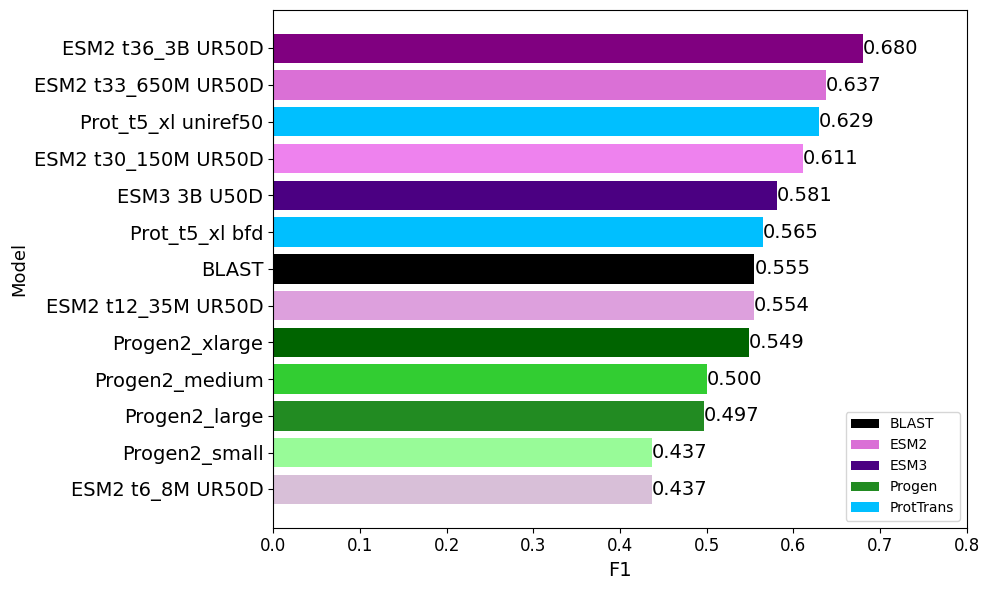

In [113]:
#Barplot (Horizontal)
fig, ax = plt.subplots(figsize=(10, 6))
df_sorted = df.sort_values('F1', ascending=True) #ascending order by F1 score
colors = df_sorted['Model_detailed'].map({
    'BLAST': 'black',
    'ESM2 t6_8M UR50D': 'thistle',
    'ESM2 t12_35M UR50D': 'plum',
    'ESM2 t30_150M UR50D': 'violet',
    'ESM2 t33_650M UR50D': 'orchid',
    'ESM2 t36_3B UR50D': 'purple',
    'ESM3 3B U50D': 'indigo',
    'Progen2_small': 'palegreen',
    'Progen2_medium': 'limegreen',
    'Progen2_large': 'forestgreen',
    'Progen2_xlarge': 'darkgreen',
    'Prot_t5_xl uniref50': 'deepskyblue',
    'Prot_t5_xl bfd': 'deepskyblue'
})
ax.barh(df_sorted['Model_detailed'], df_sorted['F1'], color=colors) #different colors for each model

#Labeling
ax.bar_label(ax.containers[0], fmt='%.3f', fontsize=14)  

ax.set_xlabel('F1', fontsize=14)
ax.set_ylabel('Model', fontsize=13)
ax.set_xlim(0, 0.8)
ax.tick_params(axis='y', labelsize=14)  
ax.tick_params(axis='x', labelsize=12)

#Legend
legend_elements = [
    Patch(facecolor='black',       label='BLAST'),
    Patch(facecolor='orchid',      label='ESM2'),
    Patch(facecolor='indigo',      label='ESM3'),
    Patch(facecolor='forestgreen', label='Progen'),
    Patch(facecolor='deepskyblue', label='ProtTrans'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('figure2.png', dpi=300, bbox_inches='tight')  
plt.show()

#References
# 1. https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.Patch.html
# 2. https://matplotlib.org/stable/gallery/lines_bars_and_markers/barh.html
# 3. https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_label_demo.html
# 4. https://matplotlib.org/stable/gallery/color/named_colors.html

